In [22]:
# Predict whether a used car is a Good Buy based on its characteristics.
import pandas as pd

data = {
    "Fuel": [
        "Petrol", "Diesel", "Petrol", "Electric", "Diesel",
        "Petrol", "Electric", "Diesel", "Petrol", "Electric"
    ],

    "Transmission": [
        "Manual", "Manual", "Automatic", "Automatic", "Manual",
        "Automatic", "Automatic", "Manual", "Manual", "Automatic"
    ],

    "Age": [
        "New", "Old", "New", "New", "Old",
        "Old", "New", "Old", "New", "New"
    ],

    "Mileage": [
        "Low", "High", "Low", "Low", "High",
        "High", "Low", "High", "Low", "Low"
    ],

    "Condition": [
        "Excellent", "Good", "Excellent", "Excellent", "Good",
        "Poor", "Excellent", "Good", "Good", "Excellent"
    ],

    "GoodBuy": [
        "Yes", "No", "Yes", "Yes", "No",
        "No", "Yes", "No", "Yes", "Yes"
    ]
}

df = pd.DataFrame(data)

print(df)

       Fuel Transmission  Age Mileage  Condition GoodBuy
0    Petrol       Manual  New     Low  Excellent     Yes
1    Diesel       Manual  Old    High       Good      No
2    Petrol    Automatic  New     Low  Excellent     Yes
3  Electric    Automatic  New     Low  Excellent     Yes
4    Diesel       Manual  Old    High       Good      No
5    Petrol    Automatic  Old    High       Poor      No
6  Electric    Automatic  New     Low  Excellent     Yes
7    Diesel       Manual  Old    High       Good      No
8    Petrol       Manual  New     Low       Good     Yes
9  Electric    Automatic  New     Low  Excellent     Yes


In [ ]:
df.shape

(10, 6)

In [ ]:
df.columns

Index(['Fuel', 'Transmission', 'Age', 'Mileage', 'Condition', 'GoodBuy'], dtype='object')

In [ ]:
df.isnull().sum()

,0
Fuel,0
Transmission,0
Age,0
Mileage,0
Condition,0
GoodBuy,0


In [ ]:
df.describe(include="object")

,Fuel,Transmission,Age,Mileage,Condition,GoodBuy
count,10,10,10,10,10,10
unique,3,2,2,2,3,2
top,Petrol,Manual,New,Low,Excellent,Yes
freq,4,5,6,6,5,6


In [ ]:
df.describe()

,Fuel,Transmission,Age,Mileage,Condition,GoodBuy
count,10,10,10,10,10,10
unique,3,2,2,2,3,2
top,Petrol,Manual,New,Low,Excellent,Yes
freq,4,5,6,6,5,6


In [ ]:
X = df.drop("GoodBuy", axis=1)
y = df["GoodBuy"]

In [ ]:
df["GoodBuy"].value_counts()

,count
GoodBuy,
Yes,6
No,4


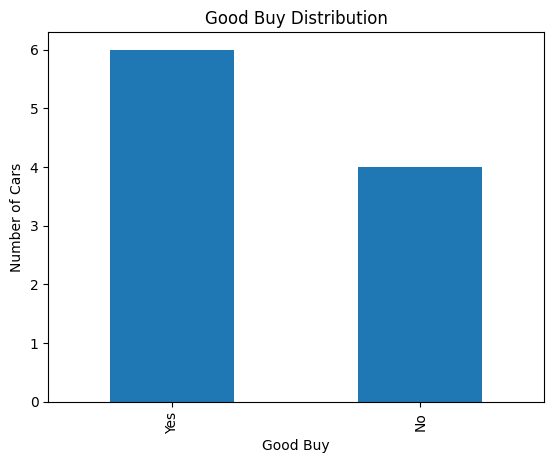

In [ ]:
import matplotlib.pyplot as plt

df["GoodBuy"].value_counts().plot(kind="bar")

plt.xlabel("Good Buy")
plt.ylabel("Number of Cars")
plt.title("Good Buy Distribution")
plt.show()

In [ ]:
pd.crosstab(df["Fuel"], df["GoodBuy"])

GoodBuy,No,Yes
Fuel,,
Diesel,3,0
Electric,0,3
Petrol,1,3


In [ ]:
pd.crosstab(df["Condition"], df["GoodBuy"])

GoodBuy,No,Yes
Condition,,
Excellent,0,5
Good,3,1
Poor,1,0


In [ ]:
pd.crosstab(df["Mileage"], df["GoodBuy"])

GoodBuy,No,Yes
Mileage,,
High,4,0
Low,0,6


In [ ]:
training_data = df.to_dict("records")

training_data

[{'Fuel': 'Petrol',
  'Transmission': 'Manual',
  'Age': 'New',
  'Mileage': 'Low',
  'Condition': 'Excellent',
  'GoodBuy': 'Yes'},
 {'Fuel': 'Diesel',
  'Transmission': 'Manual',
  'Age': 'Old',
  'Mileage': 'High',
  'Condition': 'Good',
  'GoodBuy': 'No'},
 {'Fuel': 'Petrol',
  'Transmission': 'Automatic',
  'Age': 'New',
  'Mileage': 'Low',
  'Condition': 'Excellent',
  'GoodBuy': 'Yes'},
 {'Fuel': 'Electric',
  'Transmission': 'Automatic',
  'Age': 'New',
  'Mileage': 'Low',
  'Condition': 'Excellent',
  'GoodBuy': 'Yes'},
 {'Fuel': 'Diesel',
  'Transmission': 'Manual',
  'Age': 'Old',
  'Mileage': 'High',
  'Condition': 'Good',
  'GoodBuy': 'No'},
 {'Fuel': 'Petrol',
  'Transmission': 'Automatic',
  'Age': 'Old',
  'Mileage': 'High',
  'Condition': 'Poor',
  'GoodBuy': 'No'},
 {'Fuel': 'Electric',
  'Transmission': 'Automatic',
  'Age': 'New',
  'Mileage': 'Low',
  'Condition': 'Excellent',
  'GoodBuy': 'Yes'},
 {'Fuel': 'Diesel',
  'Transmission': 'Manual',
  'Age': 'Old',
  'M

In [ ]:
target_col = "GoodBuy"

attributes = [
    col for col in training_data[0].keys()
    if col != target_col
]

print("Attributes:")
print(attributes)

Attributes:
['Fuel', 'Transmission', 'Age', 'Mileage', 'Condition']


In [ ]:
hypothesis = {attr: "0" for attr in attributes}

In [ ]:
hypothesis = {attr: "0" for attr in attributes}

print("Initial hypothesis:")
print(hypothesis)

Initial hypothesis:
{'Fuel': '0', 'Transmission': '0', 'Age': '0', 'Mileage': '0', 'Condition': '0'}


In [ ]:
history = [("h0", hypothesis.copy(), None)]

for i, example in enumerate(training_data, start=1):

    label = example[target_col]

    # Ignore negative examples
    if label != "Yes":
        print(f"Example {i} ({label}): negative → ignored")
        history.append((f"Ex{i}\n(neg)", hypothesis.copy(), False))
        continue

    # Process positive example
    for attr in attributes:

        if hypothesis[attr] == "0":
            # First positive example
            hypothesis[attr] = example[attr]

        elif hypothesis[attr] != example[attr]:
            # Different value → generalize
            hypothesis[attr] = "?"

    print(f"Example {i} ({label}): positive → h{i} = {hypothesis}")

    history.append((f"h{i}", hypothesis.copy(), True))

print("\nFinal Hypothesis:")
print(hypothesis)

Example 1 (Yes): positive → h1 = {'Fuel': 'Petrol', 'Transmission': 'Manual', 'Age': 'New', 'Mileage': 'Low', 'Condition': 'Excellent'}
Example 2 (No): negative → ignored
Example 3 (Yes): positive → h3 = {'Fuel': 'Petrol', 'Transmission': '?', 'Age': 'New', 'Mileage': 'Low', 'Condition': 'Excellent'}
Example 4 (Yes): positive → h4 = {'Fuel': '?', 'Transmission': '?', 'Age': 'New', 'Mileage': 'Low', 'Condition': 'Excellent'}
Example 5 (No): negative → ignored
Example 6 (No): negative → ignored
Example 7 (Yes): positive → h7 = {'Fuel': '?', 'Transmission': '?', 'Age': 'New', 'Mileage': 'Low', 'Condition': 'Excellent'}
Example 8 (No): negative → ignored
Example 9 (Yes): positive → h9 = {'Fuel': '?', 'Transmission': '?', 'Age': 'New', 'Mileage': 'Low', 'Condition': '?'}
Example 10 (Yes): positive → h10 = {'Fuel': '?', 'Transmission': '?', 'Age': 'New', 'Mileage': 'Low', 'Condition': '?'}

Final Hypothesis:
{'Fuel': '?', 'Transmission': '?', 'Age': 'New', 'Mileage': 'Low', 'Condition': '?'}

In [ ]:
for label, hyp, was_positive in history:
    print(f"{label.replace(chr(10), ' ')}: {hyp}")

h0: {'Fuel': '0', 'Transmission': '0', 'Age': '0', 'Mileage': '0', 'Condition': '0'}
h1: {'Fuel': 'Petrol', 'Transmission': 'Manual', 'Age': 'New', 'Mileage': 'Low', 'Condition': 'Excellent'}
Ex2 (neg): {'Fuel': 'Petrol', 'Transmission': 'Manual', 'Age': 'New', 'Mileage': 'Low', 'Condition': 'Excellent'}
h3: {'Fuel': 'Petrol', 'Transmission': '?', 'Age': 'New', 'Mileage': 'Low', 'Condition': 'Excellent'}
h4: {'Fuel': '?', 'Transmission': '?', 'Age': 'New', 'Mileage': 'Low', 'Condition': 'Excellent'}
Ex5 (neg): {'Fuel': '?', 'Transmission': '?', 'Age': 'New', 'Mileage': 'Low', 'Condition': 'Excellent'}
Ex6 (neg): {'Fuel': '?', 'Transmission': '?', 'Age': 'New', 'Mileage': 'Low', 'Condition': 'Excellent'}
h7: {'Fuel': '?', 'Transmission': '?', 'Age': 'New', 'Mileage': 'Low', 'Condition': 'Excellent'}
Ex8 (neg): {'Fuel': '?', 'Transmission': '?', 'Age': 'New', 'Mileage': 'Low', 'Condition': 'Excellent'}
h9: {'Fuel': '?', 'Transmission': '?', 'Age': 'New', 'Mileage': 'Low', 'Condition': '?

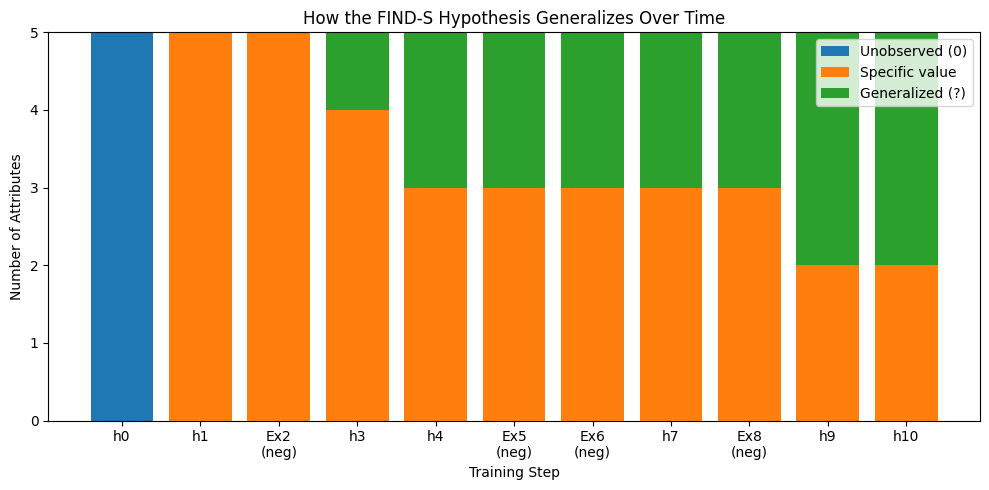

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

steps = [h[0] for h in history]

unobserved = []
specific = []
general = []

for _, hyp, _ in history:

    u = sum(1 for v in hyp.values() if v == "0")
    g = sum(1 for v in hyp.values() if v == "?")
    s = len(attributes) - u - g

    unobserved.append(u)
    specific.append(s)
    general.append(g)

x = np.arange(len(steps))

plt.figure(figsize=(10, 5))

plt.bar(x, unobserved, label="Unobserved (0)")
plt.bar(x, specific, bottom=unobserved, label="Specific value")

bottom = np.array(unobserved) + np.array(specific)

plt.bar(x, general, bottom=bottom, label="Generalized (?)")

plt.xticks(x, steps)
plt.xlabel("Training Step")
plt.ylabel("Number of Attributes")
plt.title("How the FIND-S Hypothesis Generalizes Over Time")
plt.legend()

plt.tight_layout()
plt.show()

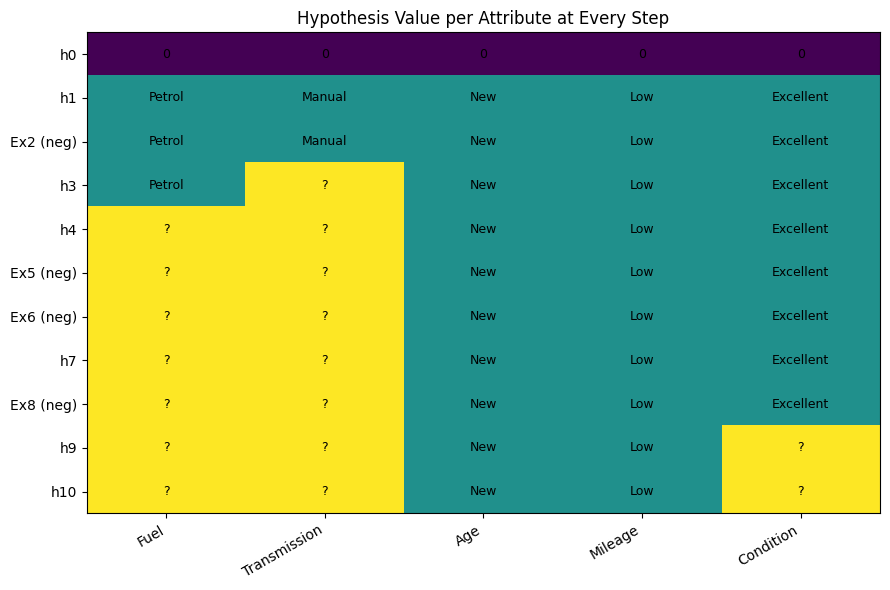

In [ ]:
grid = []

for _, hyp, _ in history:

    row = []

    for attr in attributes:

        if hyp[attr] == "0":
            row.append(0)

        elif hyp[attr] == "?":
            row.append(2)

        else:
            row.append(1)

    grid.append(row)

grid = np.array(grid)

plt.figure(figsize=(9, 6))

plt.imshow(
    grid,
    aspect="auto",
    vmin=0,
    vmax=2
)

plt.xticks(
    range(len(attributes)),
    attributes,
    rotation=30,
    ha="right"
)

plt.yticks(
    range(len(history)),
    [h[0].replace("\n", " ") for h in history]
)

# Display actual hypothesis values
for i, (_, hyp, _) in enumerate(history):

    for j, attr in enumerate(attributes):

        plt.text(
            j,
            i,
            hyp[attr],
            ha="center",
            va="center",
            fontsize=9
        )

plt.title("Hypothesis Value per Attribute at Every Step")

plt.tight_layout()
plt.show()